# Assignment 7
### Do any five.

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde, lognorm
from tqdm import trange
from scipy.stats import poisson

## 1. 

- What is the expected value of a single die roll? 
- What is the expected value of rolling two dice and adding the results together?
- What is the expected winnings of any gamble in European roulette?

- Imagine you roll a die, and you record the value you get. But, if you roll a six, you roll again, and add that value. What is the expected value?
- Imagine that the process described in the last question continues until you fail to roll a six. What is the expected value of the process? (This can be tricky, you can simulate it to get an answer if you prefer. Hint: The answer is 4.2.)

In [2]:
E_single = np.mean(np.arange(1, 7))
print("Expected value of single die roll:", E_single)

Expected value of single die roll: 3.5


In [3]:
E_two = 2 * E_single
print("Expected value of two dice summed:", E_two)

Expected value of two dice summed: 7.0


In [4]:
p_win = 1 / 37
p_lose = 36 / 37
E_roulette = p_win * 35 + p_lose * (-1)
print("Expected winnings per $1 bet in European roulette:", E_roulette)
print("House edge (%):", -E_roulette * 100, "%")

Expected winnings per $1 bet in European roulette: -0.027027027027026973
House edge (%): 2.7027027027026973 %


In [5]:
E_roll_again_if_six = (5/6)*3 + (1/6)*(6 + 3.5)
print("\nExpected value (roll again if six):", E_roll_again_if_six)


Expected value (roll again if six): 4.083333333333333


In [6]:
N = 1_000_000
rolls = np.random.randint(1, 7, size=N)
rerolls = np.random.randint(1, 7, size=N)
values = np.where(rolls == 6, rolls + rerolls, rolls)
print("Simulated expected value (roll again if six):", values.mean())

Simulated expected value (roll again if six): 4.082727


In [7]:
E_repeat_until_not6 = 21 / 5
print("\nExpected value (repeat until not 6):", E_repeat_until_not6)

def roll_until_not_6():
    total = 0
    while True:
        r = np.random.randint(1, 7)
        total += r
        if r != 6:
            break
    return total

N = 500_000
sim_vals = [roll_until_not_6() for _ in range(N)]
print("Simulated expected value (repeat until not 6):", np.mean(sim_vals))


Expected value (repeat until not 6): 4.2
Simulated expected value (repeat until not 6): 4.205586


## 2. 
- Compute the expected value for a uniform random variable.
- Show that $\mathbb{E}[a+bX] = a + b\mathbb{E}[X]$
- Show, by example, that $v(\mathbb{E}[X]) \neq \mathbb{E}[v(X)]$, if $v(x) \neq a+bx$. For example, try $v(y) = y^2$ or $v(y)=\sqrt{y}$ with a Bernoulli or uniform or normally distributed random variable. This can be an important thing to remember: The expectation of a transformed random variable is not the transformation of the expected value.

## 3. 
- Compute the variance for a uniform random variable.
- Show that 
$$
\mathbb{V}[X] = \mathbb{E}[X^2] - \mathbb{E}[X]^2
$$
$$
\mathbb{V}[a+bX] = b^2 \mathbb{V}[X]
$$
- Show that if $X$ is a normally distributed random variable, then $a + bX$ is distributed normally with mean $a+ b \mathbb{E}[X]$ and variance $b^2 \sigma_X^2$ 

These properties get used all the time!


## 4.

- The **covariance** of $X$ and $Y$ is
$$
\text{cov}(X,Y) = \int_{y} \int_{x} (x-\mathbb{E}[X])(y-\mathbb{E}[Y])f_{XY}(x,y) dxdy = \mathbb{E}_{XY}[ (x-\mu_X)(y-\mu_Y)]
$$
- Show that if $f_{XY}(x,y)=f_X(x)f_Y(y)$, then $\text{cov}(X,Y)=0$
- Provide an example (computation/simulation is fine) where $\text{cov}(X,Y)\approx 0$ but $f_{XY}(x,y)\neq 0$
- The covariance doesn't characterize joint random variables except in a few special cases: The covariance only captures the **linear** association between the two variables, not nonlinear associations.

## 5. 

Suppose $X$ has an expectation $\mathbb{E}[X]<\infty$ and variance $\mathbb{V}[X]<\infty$; this isn't always true, but is *usually* true
- Consider making a new variable, $\varepsilon = X - \mathbb{E}[X]$
- What's the expectation of $\varepsilon$?
- What's the variance of $\varepsilon$?
- So we can write any random variable in the form $X = \mathbb{E}[X] + \varepsilon, $ where $\mathbb{E}[\varepsilon]=0$ and $\mathbb{V}[\varepsilon] = \sigma_X^2$
- If that's true, show that we can also write any random variable in the form $X = \mathbb{E}[X] + \sigma_X \varepsilon$, where $\mathbb{E}[\varepsilon]=0$ and $\mathbb{V}[\varepsilon]=1$
- Now replace $\mathbb{E}[X]$ with $x\beta$, and the stage is set for regression models

## 6.
- Use the Taylor series expansions 
$$
F(x+h) = F(x) + hf(x) + \frac{h^2}{2}f'(x) + O(h^3)
$$ 
and 
$$
F(x-h) = F(x) - h f(x) + \frac{h^2}{2} f'(x)+ O(h^3)
$$
to show that
$$
\mathbb{E}[\hat{f}_{X,h}(x)] = \frac{F(x+h)-F(x-h)}{2h} = f(x) + O(h^2),
$$
so the **bias** of the KDE is $O(h^2)$, unlike the ECDF, for which $\mathbb{E}[\hat{F}(x)] = F(x)$.

## 7.
- Suppose $X$ and $Y$ are distributed bivariate normal. Show that if $\rho=0$, then $X$ and $Y$ are independent.
- For the multivariate normal, show that if $\Sigma$ is a diagonal matrix, then $X_1, X_2, ..., X_n$ are independent.
- For the multivariate normal, show that if $\Sigma$ is a diagonal matrix and all the $\sigma_i^2$ and all the $\mu_i$ are equal, then $X_1, X_2, ..., X_n$ are independently distributed random variables with distribution $N(\mu, \sigma^2)$

## 8.
- Open the METABRIC data. Make a histogram of 'Ratio Therapy'.
- Let treatment, $T$ be distributed binomial with parameter $p$. Then the contribution to the likelihood for each patient $i$, with $y_i = 0$ for no radiation therapy and $y_i=1$ for radiation therapy, is 
$$
p^{y_i}(1-p)^{1-y_i}
$$
- Write out the likelihood.
- Maximize the likelihood with respect to $p$. What is the MLE, $\hat{p}$?
- Bootstrap the sampling density/distribution of $\hat{p}$.

In [8]:
df = pd.read_csv("data/metabric.csv")

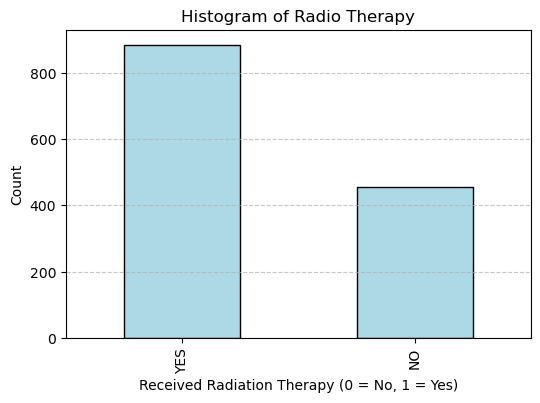

In [9]:
plt.figure(figsize=(6,4))
df["Radio Therapy"].value_counts().plot(kind='bar', color='lightblue', edgecolor='black')
plt.title("Histogram of Radio Therapy")
plt.xlabel("Received Radiation Therapy (0 = No, 1 = Yes)")
plt.ylabel("Count")
plt.grid(True, axis='y', linestyle='--', alpha=0.7)
plt.show()


In [10]:
df["Radio Therapy"] = df["Radio Therapy"].str.strip().str.lower()
df["Radio Therapy"] = df["Radio Therapy"].map({"yes": 1, "no": 0})


df = df.dropna(subset=["Radio Therapy"])

In [11]:
y = df["Radio Therapy"]
n = len(y)
y_sum = y.sum()
p_hat = y_sum / n
print(f"\nSample size n = {n}")
print(f"Number of patients with radiation therapy = {y_sum}")
print(f"MLE of p (hat p) = {p_hat:.4f}")


Sample size n = 1343
Number of patients with radiation therapy = 886
MLE of p (hat p) = 0.6597


In [12]:
B = 5000  # number of bootstrap samples
boot_p = np.empty(B)

for b in range(B):
    sample = np.random.choice(y, size=n, replace=True)
    boot_p[b] = sample.mean()

# Summary statistics of bootstrap distribution
boot_mean = np.mean(boot_p)
boot_std = np.std(boot_p, ddof=1)
ci_lower, ci_upper = np.percentile(boot_p, [2.5, 97.5])

In [13]:
boot_mean = np.mean(boot_p)
boot_std = np.std(boot_p, ddof=1)
ci_lower, ci_upper = np.percentile(boot_p, [2.5, 97.5])

print("\nBootstrap results for p_hat:")
print(f"Mean of bootstrap distribution = {boot_mean:.4f}")
print(f"Std. error (bootstrap) = {boot_std:.4f}")
print(f"95% Bootstrap CI = ({ci_lower:.4f}, {ci_upper:.4f})")


Bootstrap results for p_hat:
Mean of bootstrap distribution = 0.6596
Std. error (bootstrap) = 0.0128
95% Bootstrap CI = (0.6344, 0.6843)


<>:6: SyntaxWarning: invalid escape sequence '\h'
<>:7: SyntaxWarning: invalid escape sequence '\h'
<>:6: SyntaxWarning: invalid escape sequence '\h'
<>:7: SyntaxWarning: invalid escape sequence '\h'
/var/folders/gr/5b74bfbs70x7jql3hkfyndmm0000gn/T/ipykernel_34387/2705464735.py:6: SyntaxWarning: invalid escape sequence '\h'
  plt.title("Bootstrap Sampling Distribution of $\hat{p}$")
/var/folders/gr/5b74bfbs70x7jql3hkfyndmm0000gn/T/ipykernel_34387/2705464735.py:7: SyntaxWarning: invalid escape sequence '\h'
  plt.xlabel("$\hat{p}$ (proportion receiving therapy)")


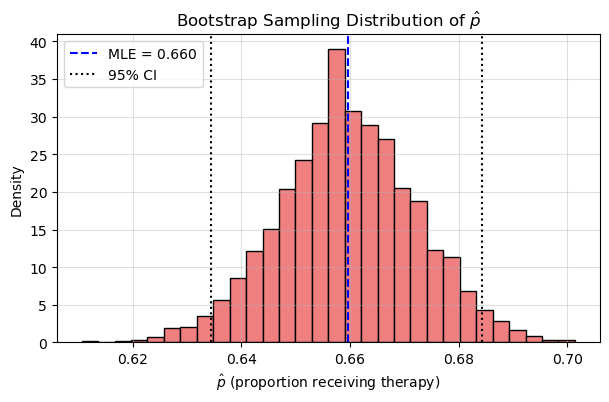

In [14]:
plt.figure(figsize=(7,4))
plt.hist(boot_p, bins=30, color='lightcoral', edgecolor='black', density=True)
plt.axvline(p_hat, color='blue', linestyle='--', label=f"MLE = {p_hat:.3f}")
plt.axvline(ci_lower, color='k', linestyle=':', label='95% CI')
plt.axvline(ci_upper, color='k', linestyle=':')
plt.title("Bootstrap Sampling Distribution of $\hat{p}$")
plt.xlabel("$\hat{p}$ (proportion receiving therapy)")
plt.ylabel("Density")
plt.legend()
plt.grid(True, alpha=0.4)
plt.show()

## 9.
- Open the Ames house price data. Make a KDE of 'price'. Select an appropriate distribution for modeling it, and explain why you selected it. (Hint: You might want to take a common transformation of price.)
- Derive the density for this distribution.
- Write out the likelihood.
- Maximize the likelihood. What is the MLE?
- Plot the density/distribution for your fitted model and compare it to the KDE/ECDF. Criticize the fit.
- Bootstrap the sampling density/distribution of your parameters.

In [15]:
df = pd.read_csv('data/ames_prices.csv')
prices = df['price'].dropna().astype(float)
prices = prices[prices > 0]
n = len(prices)

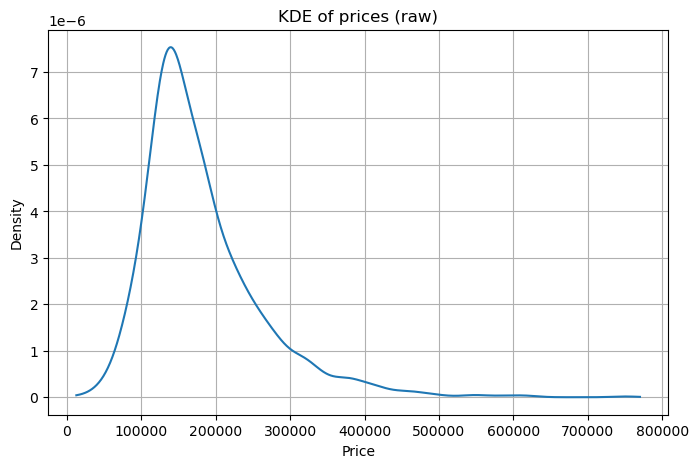

In [16]:
kde = gaussian_kde(prices)
x_grid = np.linspace(prices.min()*0.98, prices.max()*1.02, 1000)
kde_vals = kde(x_grid)
plt.figure(figsize=(8,5))
plt.plot(x_grid, kde_vals)
plt.title("KDE of prices (raw)")
plt.xlabel("Price")
plt.ylabel("Density")
plt.grid(True)
plt.show()

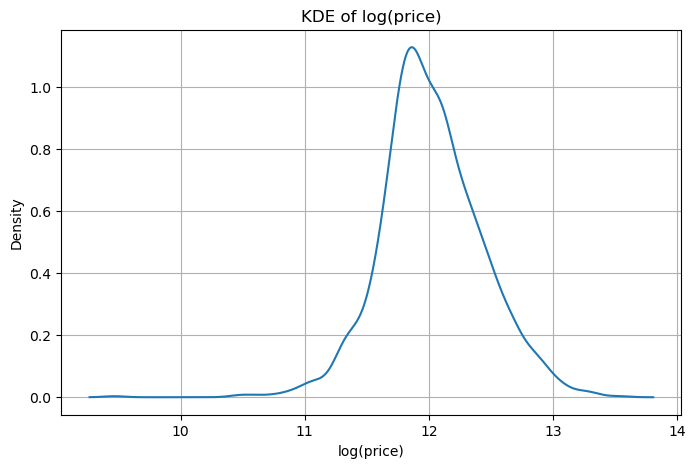

In [17]:
log_prices = np.log(prices)
kde_log = gaussian_kde(log_prices)
xlog = np.linspace(log_prices.min()*0.98, log_prices.max()*1.02, 1000)
kde_log_vals = kde_log(xlog)
plt.figure(figsize=(8,5))
plt.plot(xlog, kde_log_vals)
plt.title("KDE of log(price)")
plt.xlabel("log(price)")
plt.ylabel("Density")
plt.grid(True)
plt.show()

As you can see by taking the log of prices we remove the tail, while this does decrese the interpretability of the model it does help it to follow more of a normal distribution

In [18]:
mu_hat = np.mean(log_prices)
sigma_hat = np.std(log_prices, ddof=0)
print("MLE: mu =", mu_hat, " sigma =", sigma_hat)

MLE: mu = 12.02096869011177  sigma = 0.4075173549175143


In [19]:
median_hat = np.exp(mu_hat)
mean_hat = np.exp(mu_hat + 0.5*sigma_hat**2)
print("Model median:", median_hat, "Model mean:", mean_hat)

Model median: 166203.57810983295 Model mean: 180593.49263441682


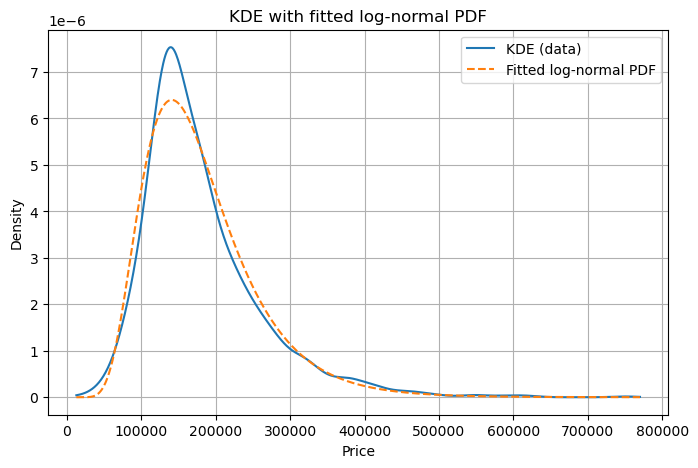

In [20]:
pdf_fitted = lognorm.pdf(x_grid, s=sigma_hat, scale=np.exp(mu_hat), loc=0)
plt.figure(figsize=(8,5))
plt.plot(x_grid, kde_vals, label='KDE (data)')
plt.plot(x_grid, pdf_fitted, label='Fitted log-normal PDF', linestyle='--')
plt.title("KDE with fitted log-normal PDF")
plt.xlabel("Price")
plt.ylabel("Density")
plt.grid(True)
plt.legend()
plt.show()

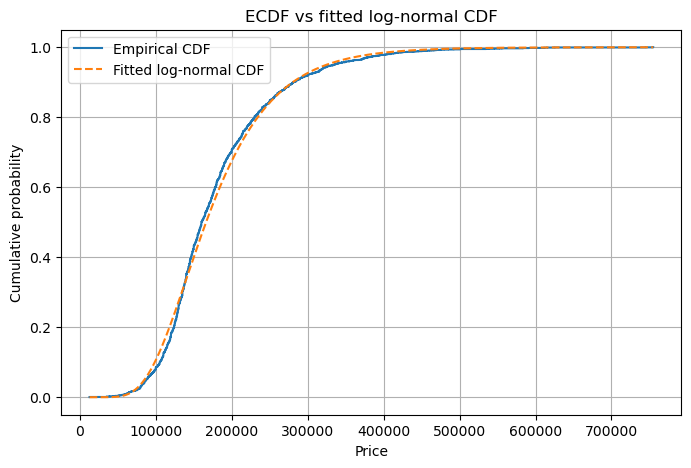

In [21]:
sorted_prices = np.sort(prices)
ecdf_y = np.arange(1, n+1)/n
cdf_fitted = lognorm.cdf(sorted_prices, s=sigma_hat, scale=np.exp(mu_hat), loc=0)
plt.figure(figsize=(8,5))
plt.step(sorted_prices, ecdf_y, where='post', label='Empirical CDF')
plt.plot(sorted_prices, cdf_fitted, label='Fitted log-normal CDF', linestyle='--')
plt.title("ECDF vs fitted log-normal CDF")
plt.xlabel("Price")
plt.ylabel("Cumulative probability")
plt.grid(True)
plt.legend()
plt.show()

Honestly this seems like an really good fit in both examples, it does not perfectly match the shape of the KDE plot though

In [22]:
R = 2000
mu_boot = np.empty(R)
sigma_boot = np.empty(R)
rng = np.random.default_rng(12345)
for i in trange(R):
    sample = rng.choice(prices, size=n, replace=True)
    log_sample = np.log(sample)
    mu_boot[i] = np.mean(log_sample)
    sigma_boot[i] = np.std(log_sample, ddof=0)

100%|██████████| 2000/2000 [00:00<00:00, 20414.81it/s]


Bootstrap 95% CI for mu: [12.00688197 12.03616304]
Bootstrap 95% CI for sigma: [0.39361058 0.42156994]


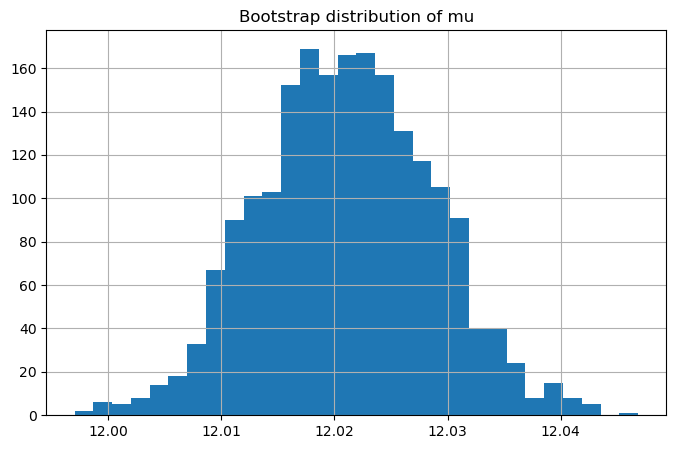

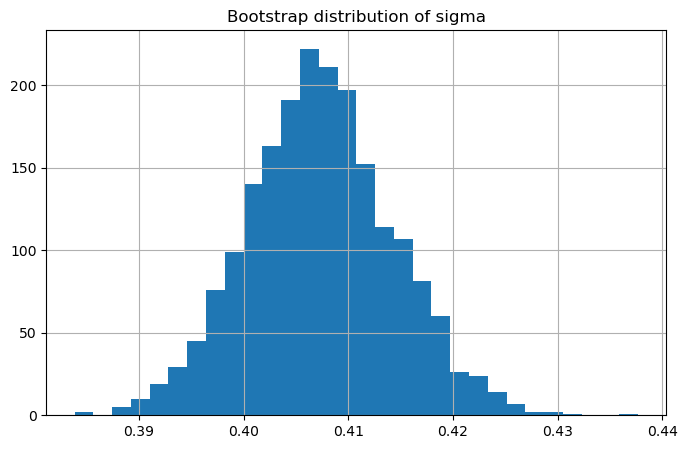

In [23]:
mu_ci = np.percentile(mu_boot, [2.5, 97.5])
sigma_ci = np.percentile(sigma_boot, [2.5, 97.5])
print("Bootstrap 95% CI for mu:", mu_ci)
print("Bootstrap 95% CI for sigma:", sigma_ci)

plt.figure(figsize=(8,5))
plt.hist(mu_boot, bins=30)
plt.title("Bootstrap distribution of mu")
plt.grid(True)
plt.show()

plt.figure(figsize=(8,5))
plt.hist(sigma_boot, bins=30)
plt.title("Bootstrap distribution of sigma")
plt.grid(True)
plt.show()

## 10.
- Open the METABRIC data. Make a KDE of 'Overall Survival (Months)'.
- Let survival time, $T$ be distributed exponentially with parameter $\lambda$. Then its distribution is
$$
F(t) = 1 - e^{-\lambda t} = p[T\le t].
$$
- Derive the density for this distribution.
- Write out the likelihood.
- Maximize the likelihood with respect to $\lambda$. What is the MLE, $\hat{\lambda}$?
- Plot the density/distribution for your fitted model and compare it to the KDE/ECDF. Criticize the fit.
- Bootstrap the sampling density/distribution of $\hat{\lambda}$.

In [24]:
df = pd.read_csv("data/metabric.csv")
df["Overall Survival (Months)"] = pd.to_numeric(df["Overall Survival (Months)"], errors="coerce")
surv = df["Overall Survival (Months)"].dropna()
n = len(surv)

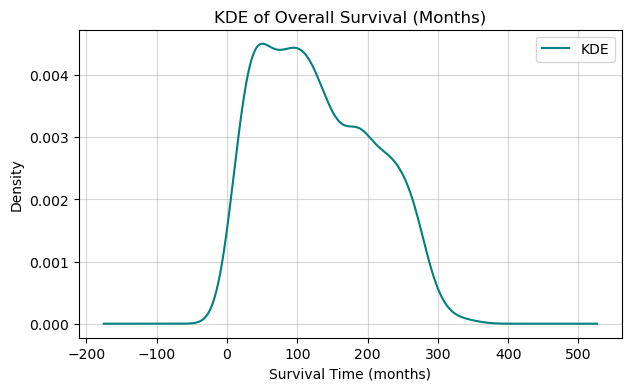

In [25]:
plt.figure(figsize=(7,4))
surv.plot(kind='kde', color='teal', label='KDE')
plt.title("KDE of Overall Survival (Months)")
plt.xlabel("Survival Time (months)")
plt.ylabel("Density")
plt.legend()
plt.grid(alpha=0.5)
plt.show()

In [26]:
lambda_hat = n / surv.sum()
print(f"Sample size n = {n}")
print(f"Mean survival time = {surv.mean():.2f} months")
print(f"MLE λ̂ = {lambda_hat:.5f} (1/months)")

Sample size n = 1343
Mean survival time = 129.09 months
MLE λ̂ = 0.00775 (1/months)


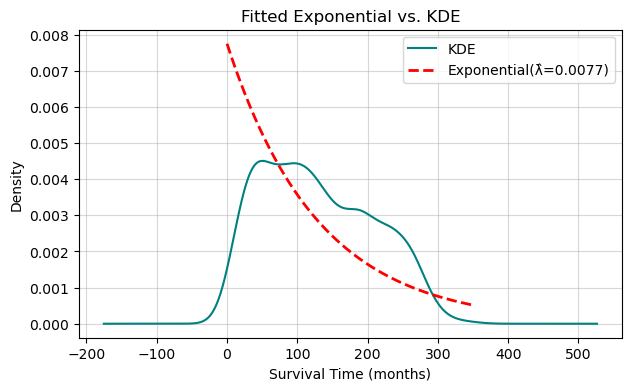

In [27]:
x = np.linspace(0, surv.max(), 500)
exp_pdf = lambda_hat * np.exp(-lambda_hat * x)

plt.figure(figsize=(7,4))
surv.plot(kind='kde', color='teal', label='KDE')
plt.plot(x, exp_pdf, 'r--', lw=2, label=f'Exponential(λ̂={lambda_hat:.4f})')
plt.title("Fitted Exponential vs. KDE")
plt.xlabel("Survival Time (months)")
plt.ylabel("Density")
plt.legend()
plt.grid(alpha=0.5)
plt.show()

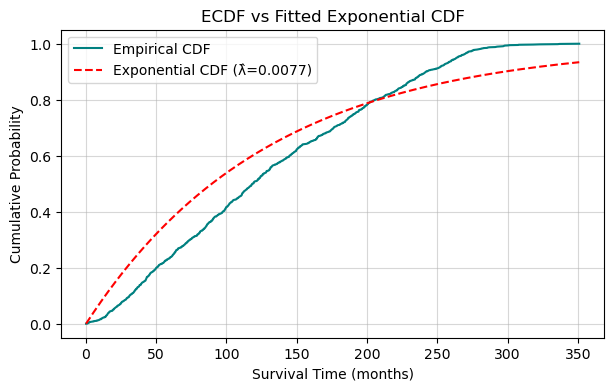

In [28]:
sorted_surv = np.sort(surv)
ecdf = np.arange(1, n+1) / n
exp_cdf = 1 - np.exp(-lambda_hat * sorted_surv)

plt.figure(figsize=(7,4))
plt.plot(sorted_surv, ecdf, label='Empirical CDF', color='teal')
plt.plot(sorted_surv, exp_cdf, 'r--', label=f'Exponential CDF (λ̂={lambda_hat:.4f})')
plt.title("ECDF vs Fitted Exponential CDF")
plt.xlabel("Survival Time (months)")
plt.ylabel("Cumulative Probability")
plt.legend()
plt.grid(alpha=0.5)
plt.show()

I think it does much better with the CDF then it does with the KDE. with the CDF if follows the same general shape, but does over and under predict depending on the area of the graph. Overall though I'd say it doesn't seem like a very good fit for either graph.

In [29]:
B = 5000
boot_lambda = np.empty(B)
for b in range(B):
    sample = np.random.choice(surv, size=n, replace=True)
    boot_lambda[b] = 1 / sample.mean()

boot_mean = boot_lambda.mean()
boot_std = boot_lambda.std(ddof=1)
ci_lower, ci_upper = np.percentile(boot_lambda, [2.5, 97.5])

print("\nBootstrap results for λ̂:")
print(f"Mean of bootstrap λ̂ = {boot_mean:.5f}")
print(f"Std. error (bootstrap) = {boot_std:.5f}")
print(f"95% CI = ({ci_lower:.5f}, {ci_upper:.5f})")



Bootstrap results for λ̂:
Mean of bootstrap λ̂ = 0.00775
Std. error (bootstrap) = 0.00013
95% CI = (0.00750, 0.00802)


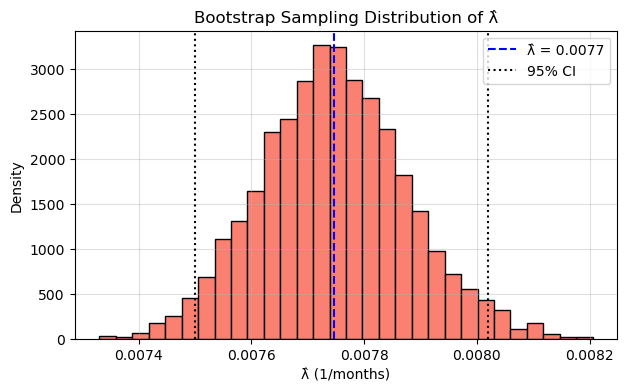

In [30]:
plt.figure(figsize=(7,4))
plt.hist(boot_lambda, bins=30, color='salmon', edgecolor='black', density=True)
plt.axvline(lambda_hat, color='blue', linestyle='--', label=f"λ̂ = {lambda_hat:.4f}")
plt.axvline(ci_lower, color='k', linestyle=':', label='95% CI')
plt.axvline(ci_upper, color='k', linestyle=':')
plt.title("Bootstrap Sampling Distribution of λ̂")
plt.xlabel("λ̂ (1/months)")
plt.ylabel("Density")
plt.legend()
plt.grid(alpha=0.4)
plt.show()

## 11.
- Open the Ames house price data. Make a histogram of 'TotRms.AbvGrd', or total rooms above ground.
- We're going to model this using the Poisson Distribution. The probability that $y_i = k$ is given by
$$
pr[y_i = k ] = \frac{ \lambda^k e^{-\lambda} }{k!}
$$
- Write out the likelihood.
- Maximize the likelihood. What is the MLE? (Hint: The sample mean. As usual.)
- Plot the density/distribution for your fitted model and compare it to the KDE/ECDF. Criticize the fit.
- Bootstrap the sampling density/distribution of your parameter.

In [31]:
df = pd.read_csv("data/ames_prices.csv")
rooms = df["TotRms.AbvGrd"].dropna()
n = len(rooms)

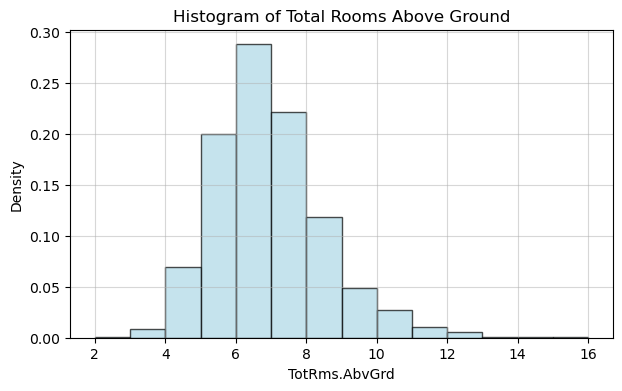

In [32]:
plt.figure(figsize=(7,4))
plt.hist(rooms, bins=range(int(rooms.min()), int(rooms.max())+2), 
         color='lightblue', edgecolor='black', alpha=0.7, density=True)
plt.title("Histogram of Total Rooms Above Ground")
plt.xlabel("TotRms.AbvGrd")
plt.ylabel("Density")
plt.grid(alpha=0.5)
plt.show()

In [33]:
lambda_hat = rooms.mean()
print(f"Sample size n = {n}")
print(f"Mean number of rooms = {lambda_hat:.3f}")
print(f"MLE of λ = {lambda_hat:.3f}")

Sample size n = 2930
Mean number of rooms = 6.443
MLE of λ = 6.443


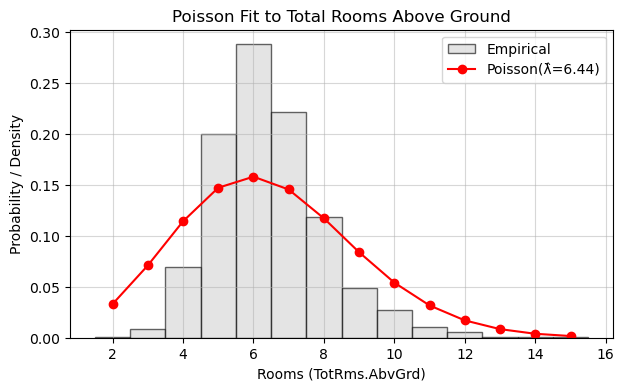

In [34]:
x_vals = np.arange(rooms.min(), rooms.max()+1)
pois_pmf = poisson.pmf(x_vals, mu=lambda_hat)

plt.figure(figsize=(7,4))
plt.hist(rooms, bins=np.arange(rooms.min()-0.5, rooms.max()+1.5, 1), 
         color='lightgray', edgecolor='black', alpha=0.6, density=True, label="Empirical")
plt.plot(x_vals, pois_pmf, 'r-o', label=f'Poisson(λ̂={lambda_hat:.2f})')
plt.title("Poisson Fit to Total Rooms Above Ground")
plt.xlabel("Rooms (TotRms.AbvGrd)")
plt.ylabel("Probability / Density")
plt.legend()
plt.grid(alpha=0.5)
plt.show()

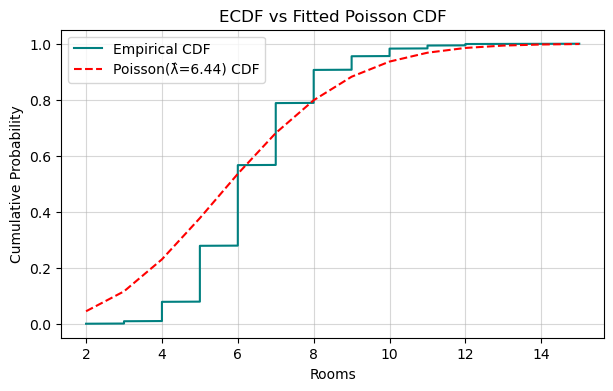

In [35]:
sorted_y = np.sort(rooms)
ecdf = np.arange(1, n+1) / n
pois_cdf = poisson.cdf(sorted_y, mu=lambda_hat)

plt.figure(figsize=(7,4))
plt.plot(sorted_y, ecdf, label="Empirical CDF", color="teal")
plt.plot(sorted_y, pois_cdf, "r--", label=f"Poisson(λ̂={lambda_hat:.2f}) CDF")
plt.title("ECDF vs Fitted Poisson CDF")
plt.xlabel("Rooms")
plt.ylabel("Cumulative Probability")
plt.legend()
plt.grid(alpha=0.5)
plt.show()

I think the poisson does an overall good job of showing the trend, however it does over predict the probability at the beginning. I also think it does a poor job of showcasing the staircase nature of the data, I understand that it smooths and is supposed to be a trend line. But it is something to note that with the fact that this data is not continuous it leads to over and underpredictions as the poisson tries to adapt.

In [36]:
B = 5000
boot_lambda = np.empty(B)

for b in range(B):
    sample = np.random.choice(rooms, size=n, replace=True)
    boot_lambda[b] = sample.mean()

boot_mean = np.mean(boot_lambda)
boot_std = np.std(boot_lambda, ddof=1)
ci_lower, ci_upper = np.percentile(boot_lambda, [2.5, 97.5])

print("\nBootstrap results for λ̂:")
print(f"Mean of bootstrap λ̂ = {boot_mean:.4f}")
print(f"Std. error (bootstrap) = {boot_std:.4f}")
print(f"95% CI = ({ci_lower:.4f}, {ci_upper:.4f})")


Bootstrap results for λ̂:
Mean of bootstrap λ̂ = 6.4435
Std. error (bootstrap) = 0.0287
95% CI = (6.3877, 6.5000)


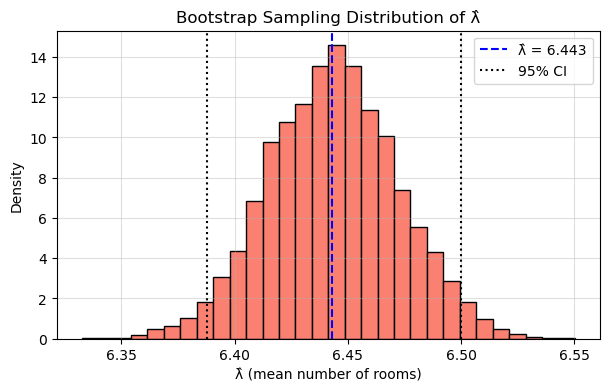

In [37]:
plt.figure(figsize=(7,4))
plt.hist(boot_lambda, bins=30, color='salmon', edgecolor='black', density=True)
plt.axvline(lambda_hat, color='blue', linestyle='--', label=f"λ̂ = {lambda_hat:.3f}")
plt.axvline(ci_lower, color='k', linestyle=':', label='95% CI')
plt.axvline(ci_upper, color='k', linestyle=':')
plt.title("Bootstrap Sampling Distribution of λ̂")
plt.xlabel("λ̂ (mean number of rooms)")
plt.ylabel("Density")
plt.legend()
plt.grid(alpha=0.4)
plt.show()

## 12.
- Open the METABRIC data. Make a histogram of 'Mutation Count' with around 50 bins. Let $Y$ be the mutation count the random variable, and $y_i$ the mutation count for patient $i$.
- We're going to model this using the Poisson Distribution. The probability that $y_i = k$ is given by
$$
pr[y_i = k ] = \frac{ \lambda^k e^{-\lambda} }{k!}
$$
- Write out the likelihood.
- Maximize the likelihood. What is the MLE? (Hint: The sample mean. As usual.)
- Plot the density/distribution for your fitted model and compare it to the KDE/ECDF. Criticize the fit.
- Bootstrap the sampling density/distribution of your parameter.

In [38]:
df = pd.read_csv("data/metabric.csv")

In [39]:
df["Mutation Count"] = pd.to_numeric(df["Mutation Count"], errors="coerce")
mut = df["Mutation Count"].dropna()
n = len(mut)

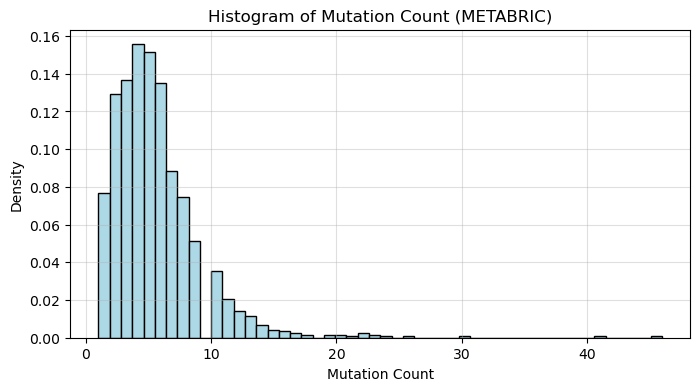

In [40]:
plt.figure(figsize=(8,4))
plt.hist(mut, bins=50, color='lightblue', edgecolor='black', density=True)
plt.title("Histogram of Mutation Count (METABRIC)")
plt.xlabel("Mutation Count")
plt.ylabel("Density")
plt.grid(alpha=0.4)
plt.show()


In [41]:
lambda_hat = mut.mean()
print(f"Sample size n = {n}")
print(f"Mean mutation count = {lambda_hat:.3f}")
print(f"MLE of λ = {lambda_hat:.3f}")

Sample size n = 1343
Mean mutation count = 5.494
MLE of λ = 5.494


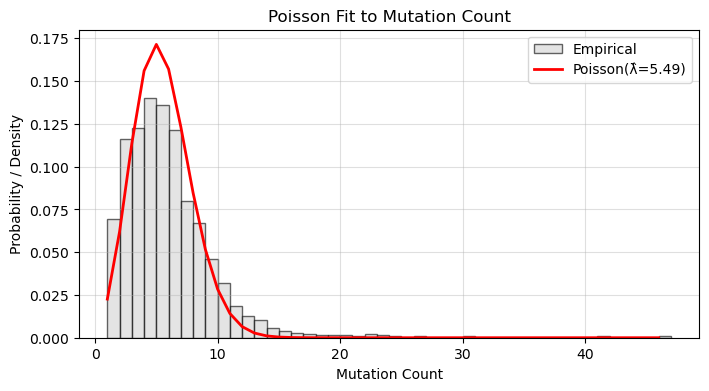

In [42]:
x_vals = np.arange(int(mut.min()), int(mut.max())+1)
pois_pmf = poisson.pmf(x_vals, mu=lambda_hat)

plt.figure(figsize=(8,4))
plt.hist(mut, bins=range(int(mut.min()), int(mut.max())+2), 
         color='lightgray', edgecolor='black', alpha=0.6, density=True, label="Empirical")
plt.plot(x_vals, pois_pmf, 'r-', lw=2, label=f"Poisson(λ̂={lambda_hat:.2f})")
plt.title("Poisson Fit to Mutation Count")
plt.xlabel("Mutation Count")
plt.ylabel("Probability / Density")
plt.legend()
plt.grid(alpha=0.4)
plt.show()


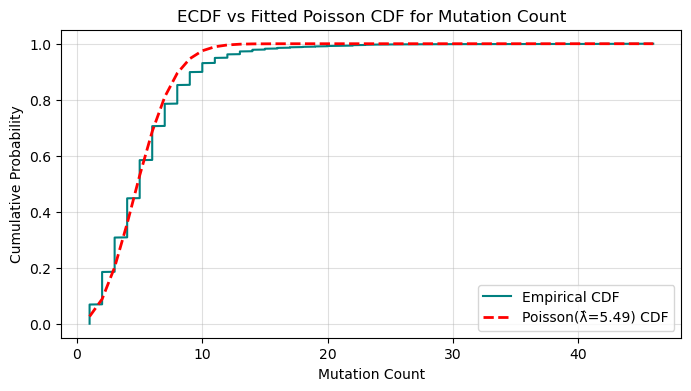

In [43]:
sorted_y = np.sort(mut)
ecdf = np.arange(1, n+1) / n
pois_cdf = poisson.cdf(sorted_y, mu=lambda_hat)

plt.figure(figsize=(8,4))
plt.plot(sorted_y, ecdf, label="Empirical CDF", color="teal")
plt.plot(sorted_y, pois_cdf, "r--", lw=2, label=f"Poisson(λ̂={lambda_hat:.2f}) CDF")
plt.title("ECDF vs Fitted Poisson CDF for Mutation Count")
plt.xlabel("Mutation Count")
plt.ylabel("Cumulative Probability")
plt.legend()
plt.grid(alpha=0.4)
plt.show()

It overpredicts a lot around 10 for both the ECDF and KDE. I also think that again the non-continuous nature of the data is hurting it leading to over/under predicting as the CDF moves upwards in a staircase fashion. It underpredicts at the beginning of the KDE and then overpredicts at around 10.

In [44]:
B = 5000
boot_lambda = np.empty(B)

for b in range(B):
    sample = np.random.choice(mut, size=n, replace=True)
    boot_lambda[b] = sample.mean()

boot_mean = np.mean(boot_lambda)
boot_std = np.std(boot_lambda, ddof=1)
ci_lower, ci_upper = np.percentile(boot_lambda, [2.5, 97.5])

print("\nBootstrap results for λ̂:")
print(f"Mean of bootstrap λ̂ = {boot_mean:.4f}")
print(f"Std. error (bootstrap) = {boot_std:.4f}")
print(f"95% CI = ({ci_lower:.4f}, {ci_upper:.4f})")


Bootstrap results for λ̂:
Mean of bootstrap λ̂ = 5.4945
Std. error (bootstrap) = 0.1024
95% CI = (5.2956, 5.7022)


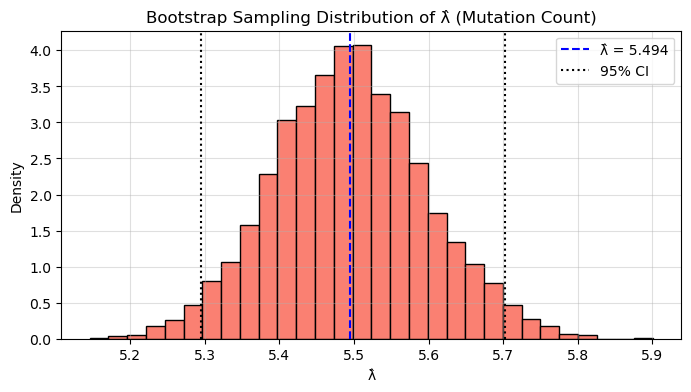

In [45]:
plt.figure(figsize=(8,4))
plt.hist(boot_lambda, bins=30, color='salmon', edgecolor='black', density=True)
plt.axvline(lambda_hat, color='blue', linestyle='--', label=f"λ̂ = {lambda_hat:.3f}")
plt.axvline(ci_lower, color='k', linestyle=':', label='95% CI')
plt.axvline(ci_upper, color='k', linestyle=':')
plt.title("Bootstrap Sampling Distribution of λ̂ (Mutation Count)")
plt.xlabel("λ̂")
plt.ylabel("Density")
plt.legend()
plt.grid(alpha=0.4)
plt.show()